In [22]:
import matplotlib.pyplot as plt
from qutip import *
import numpy as np

from tomo_plot_hammer import *

In [23]:
spin_dim = 7/2
Ix = jmat(spin_dim,'x')
Iy = jmat(spin_dim,'y')
Iz = jmat(spin_dim,'z')
Ix_square = Ix * Ix
Iz_square = Iz * Iz
Ip = jmat(spin_dim, '+')
Im = jmat(spin_dim, '-')

def Hz_order(kappa, order):
    H = kappa * Iz **(order) / (order * (7/2) ** (order -1 ))
    return H

# Direct Evolution

In [24]:
# Hilbert space dimension
d = 8

# non-linear strength in radians
kappa = 2*np.pi*400

Hzz = Hz_order(kappa, 3)

# su(2) drivign strength
rabi_strength = 2*np.pi*1/(2*(1888409/1e9))

Hy = rabi_strength * -Iy#-Iy

H_drive = Hy + Hzz

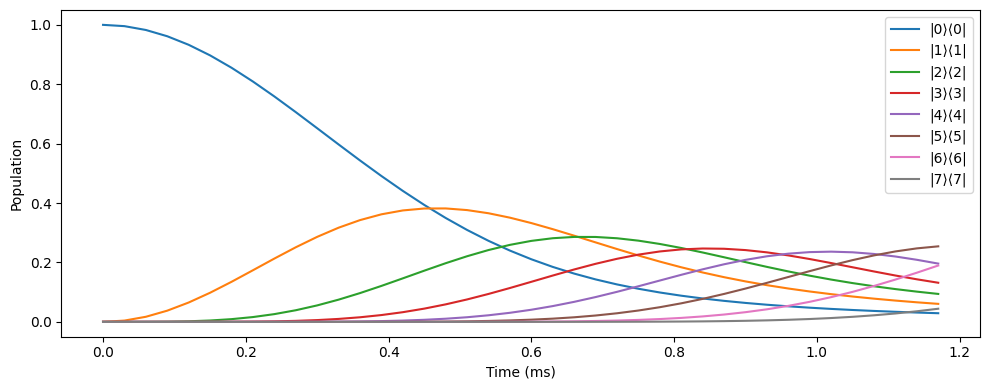

In [25]:
# ----- Time domain setup -----
t_max = 1.2e-3
t_step = 30e-6
time = np.arange(0, t_max, t_step)
N = len(time)

# Initial state and density matrix
psi0 = basis(d, 0)
rho0 = psi0 * psi0.dag()

# Preallocate trajectory (avoid shared references)
rho_t_direct = [None] * N
rho_t_direct[0] = rho0

# Expectation of projectors onto |j><j|
exp_comps = np.zeros((d, N), dtype=float)  # rows: components, cols: time
exp_comps[:, 0] = np.real(np.diag(rho0.full())).ravel()

for n in range(1, N):
    H = H_drive                       # your Hamiltonian (Qobj)
    HH = -1j * t_step * Qobj(H)
    U = HH.expm()
    rho_t_direct[n] = U * rho_t_direct[n-1] * U.dag()

    # Fill diagonal populations (projectors |j><j|)
    for j in range(d):
        proj_j = basis(d, j) * basis(d, j).dag()
        exp_comps[j, n] = expect(proj_j, rho_t_direct[n]).real

# ---- Plotting ----

plt.figure(figsize=(10,4))
for j in range(d):
    plt.plot(time*1e3, exp_comps[j, :], label=f'|{j}⟩⟨{j}|')

plt.xlabel('Time (ms)')
plt.ylabel('Population')
plt.legend()
plt.tight_layout()
plt.show()

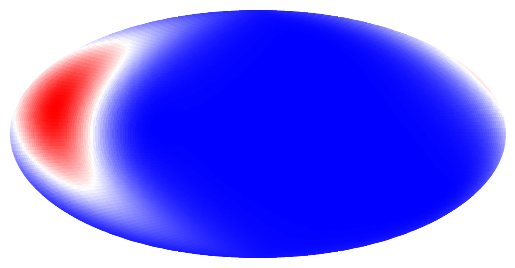

<HammerAxes: >

In [26]:
tomo_plot_hammer(rho_t_direct[-1], "h")

# Trotterization

In [27]:
psi0 = basis(d, 0)
rho0 = psi0 * psi0.dag()
projectors = [basis(d, j) * basis(d, j).dag() for j in range(d)]

# Storage as indexable lists
rho_trajectories = []   # [sweep_idx][n] -> Qobj density matrix
exp_comps_all   = []    # [sweep_idx] -> array shape (d, trotter_num+1)
step_idx_all    = []    # [sweep_idx] -> np.arange(trotter_num+1)

# when we sweep dt from 100 µs to 1500 µs
trotter_num_max = 20
trotter_num_list = np.arange(1,trotter_num_max + 1)
# trotter_steps = np.arange(100e-6, 1200e-6 + 1e-12, 10e-6)


for trotter_num in trotter_num_list:
    # trotter_num = int(np.floor(t_max / dt))  # integer # of steps for this dt
    dt = t_max / trotter_num
    # Allocate
    rho_t = [None] * (trotter_num + 1)
    rho_t[0] = rho0

    exp_comps = np.zeros((d, trotter_num + 1), dtype=float)
    exp_comps[:, 0] = np.real(np.diag(rho0.full())).ravel()

    # Precompute single-step unitary for this dt (time-independent Trotter-1)
    Uy  = (-1j * dt * Qobj(Hy)).expm()
    Uzz = (-1j * dt * Qobj(Hzz)).expm()
    U   = Uzz * Uy

    # Loop n = 0..trotter_num (inclusive); n=0 is already initialized
    for n in range(0, trotter_num + 1):
        if n == 0:
            continue
        rho_t[n] = U * rho_t[n - 1] * U.dag()
        for j, Pj in enumerate(projectors):
            exp_comps[j, n] = expect(Pj, rho_t[n]).real

    # Store for this sweep
    rho_trajectories.append(rho_t)
    exp_comps_all.append(exp_comps)
    step_idx_all.append(np.arange(trotter_num + 1))


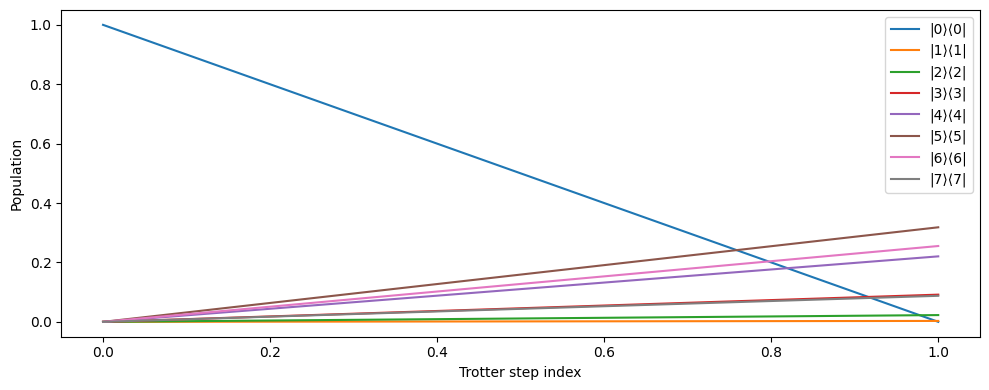

In [28]:
# ----- Example plot (by sweep index, using step index on x-axis) -----
plot_sweep = 0
plt.figure(figsize=(10, 4))
for j in range(d):
    plt.plot(step_idx_all[plot_sweep], exp_comps_all[plot_sweep][j, :], label=f'|{j}⟩⟨{j}|')

plt.xlabel('Trotter step index')
plt.ylabel('Population')
# plt.title(f'Trotter Step Index {plot_sweep} (dt = {1000*trotter_steps[plot_sweep]:.1e} ms)')
plt.legend()
plt.tight_layout()
plt.show()

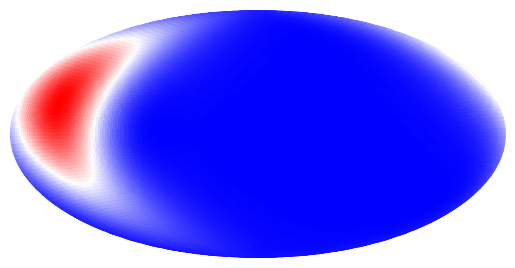

<HammerAxes: >

In [29]:
tortter_num_idx = 19
step_ind = -1
tomo_plot_hammer(rho_trajectories[tortter_num_idx][step_ind], "h")

# Comparing the overlap between DQS and direct evolution

In [30]:
# Define Iz operator for spin j
j = 7/2   # adjust to your system
Iz = jmat(j, 'z')

# Reference final state
rho_ref = rho_t_direct[-1]

# Final states from each trajectory
final_rhos = [rho_list[-1] for rho_list in rho_trajectories]
fids = np.array([fidelity(rho_i, rho_ref) for rho_i in final_rhos])

# Expectation values of Iz
Iz_ref = expect(Iz, rho_ref)
Iz_vals = np.array([expect(Iz, rho_i) for rho_i in final_rhos])

# Differences relative to reference
Iz_diffs = np.abs(Iz_vals - Iz_ref)

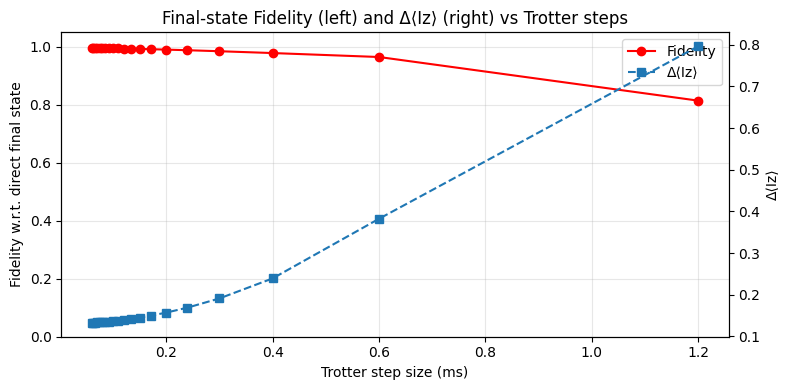

In [31]:
# Twin-axis plot: left=fidelity, right=Iz
fig, ax1 = plt.subplots(figsize=(8,4))

# Left axis: Fidelity
n = min(len(trotter_num_list), len(fids), len(Iz_diffs))
x = 1e3* t_max/trotter_num_list[:n]
l1, = ax1.plot(x, fids, marker='o', label='Fidelity', color = 'red')
ax1.set_xlabel("Trotter step size (ms)")
ax1.set_ylabel("Fidelity w.r.t. direct final state")
ax1.set_ylim(0.0, 1.05)        # fixed fidelity scale

# Right axis: Δ⟨Iz⟩
ax2 = ax1.twinx()
l2, = ax2.plot(x, Iz_diffs, marker='s', linestyle='--', label='Δ⟨Iz⟩')
ax2.set_ylabel("Δ⟨Iz⟩")

# One combined legend
ax1.legend([l1, l2], ["Fidelity", "Δ⟨Iz⟩"], loc="best")

ax1.grid(True, alpha=0.3)
plt.title("Final-state Fidelity (left) and Δ⟨Iz⟩ (right) vs Trotter steps")
fig.tight_layout()
plt.show()

# Sweep total evolution time

In [32]:
# Hilbert space dimension
d = 8

# non-linear strength in radians
kappa = 2*np.pi*100

Hzz = Hz_order(kappa, 2)

# su(2) drivign strength
rabi_strength = 2*np.pi*1/(2*(1888409/1e9))

Hy = rabi_strength * -Iy#-Iy

H_drive = Hy + Hzz

In [33]:
# ----- Time domain + direct evolution sweep -----
# Assumes: import numpy as np, from qutip import *
# Uses: d, H_drive already defined

# Sweep list for t_max (10 linearly spaced values from 1e-3 to 10e-3)
t_max_list = np.linspace(1e-3, 10e-3, 10)

t_step = 30e-6  # fixed time step
psi0 = basis(d, 0)
rho0 = psi0 * psi0.dag()
projectors = [basis(d, j) * basis(d, j).dag() for j in range(d)]

# Storage per t_max sweep
time_all_direct      = []  # list of np.ndarray time axes
rho_traj_all_direct  = []  # list of lists: [sweep_idx][n] -> Qobj rho
exp_comps_all_direct = []  # list of arrays: [sweep_idx] -> (d, N)

for t_max in t_max_list:
    # Time grid for this sweep
    time = np.arange(0, t_max, t_step)
    N = len(time)

    # Preallocate trajectory (avoid shared references)
    rho_t_direct = [None] * N
    rho_t_direct[0] = rho0

    # Diagonal populations (|j><j|)
    exp_comps = np.zeros((d, N), dtype=float)
    exp_comps[:, 0] = np.real(np.diag(rho0.full())).ravel()

    # Single-step propagator is constant if H_drive is time-independent
    HH = -1j * t_step * Qobj(H_drive)
    U = HH.expm()

    # Propagate
    for n in range(1, N):
        rho_t_direct[n] = U * rho_t_direct[n-1] * U.dag()
        for j, Pj in enumerate(projectors):
            exp_comps[j, n] = expect(Pj, rho_t_direct[n]).real

    # Store for this t_max
    time_all_direct.append(time)
    rho_traj_all_direct.append(rho_t_direct)
    exp_comps_all_direct.append(exp_comps)


In [34]:
# ----- Trotter (first-order) sweep -----
# Assumes: from qutip import *
# Uses: d, Hy, Hzz already defined (so that U ≈ e^{-i dt Hy} e^{-i dt Hzz})
# Matches the original behavior (varies trotter_num for each t_max)

# Sweep list for t_max (10 linearly spaced values from 1e-3 to 10e-3)
t_max_list = np.linspace(1e-3, 10e-3, 10)

psi0 = basis(d, 0)
rho0 = psi0 * psi0.dag()
projectors = [basis(d, j) * basis(d, j).dag() for j in range(d)]

# We'll reuse your trotter_num_list for each t_max
trotter_num = 50
trotter_num_list = np.flip(np.arange(1, trotter_num+1))  # [12,11,...,1]

# Top-level storage per t_max
# Each entry (one per t_max) mirrors the original containers
trotter_results = []  # list of dicts, one dict per t_max

for t_max in t_max_list:
    rho_trajectories = []  # [sweep_idx=per trotter_num][n] -> Qobj rho
    exp_comps_all    = []  # [sweep_idx] -> (d, trotter_num+1)
    step_idx_all     = []  # [sweep_idx] -> np.arange(trotter_num+1)

    # For each trotter count, set dt = t_max / trotter_num and propagate
    for trotter_num in trotter_num_list:
        trotter_num = int(trotter_num)
        dt = t_max / trotter_num

        # Allocate trajectory
        rho_t = [None] * (trotter_num + 1)
        rho_t[0] = rho0

        # Populations
        exp_comps = np.zeros((d, trotter_num + 1), dtype=float)
        exp_comps[:, 0] = np.real(np.diag(rho0.full())).ravel()

        # Precompute single-step first-order Trotter unitary
        Uy  = (-1j * dt * Qobj(Hy)).expm()
        # Uz  = (-1j * dt * Qobj(Hz)).expm()
        Uzz = (-1j * dt * Qobj(Hzz)).expm()
        U   = Uy * Uzz

        # Steps 1..trotter_num
        for n in range(1, trotter_num + 1):
            rho_t[n] = U * rho_t[n - 1] * U.dag()
            for j, Pj in enumerate(projectors):
                exp_comps[j, n] = expect(Pj, rho_t[n]).real

        # Store for this trotter_num
        rho_trajectories.append(rho_t)
        exp_comps_all.append(exp_comps)
        step_idx_all.append(np.arange(trotter_num + 1))

    # Store the whole set for this t_max
    trotter_results.append({
        "t_max": t_max,
        "trotter_num_list": trotter_num_list.copy(),
        "rho_trajectories": rho_trajectories,
        "exp_comps_all": exp_comps_all,
        "step_idx_all": step_idx_all,
    })

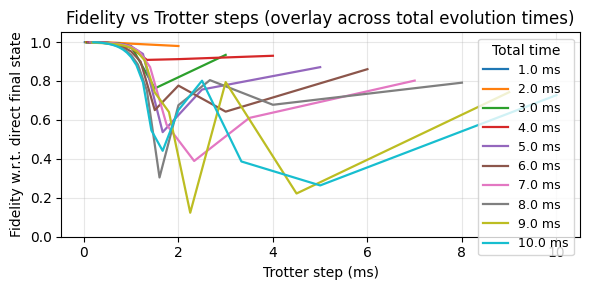

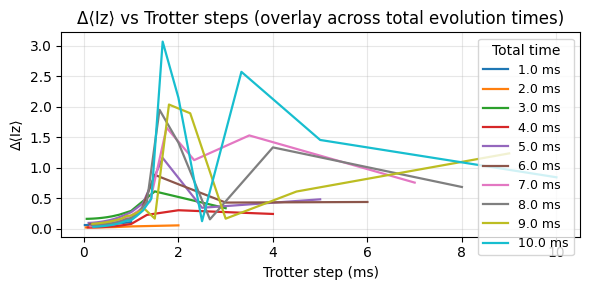

In [35]:
# ----- Separate overlay plots: Fidelity and Δ⟨Iz⟩ vs Trotter steps -----
from qutip import fidelity, expect, jmat
import numpy as np
import matplotlib.pyplot as plt

# Spin operator (adjust j if needed)
j = 7/2
Iz = jmat(j, 'z')

assert len(rho_traj_all_direct) == len(trotter_results), "Mismatch: direct vs trotter sweep lengths."

# Containers for legends (shared across both plots so colors/ordering match)
labels = [f"{TR['t_max']*1e3:.1f} ms" for TR in trotter_results]

# -------- Plot 1: Fidelity vs Trotter steps (overlay by t_max) --------
plt.figure(figsize=(6, 3))
handles_f = []

for idx, TR in enumerate(trotter_results):
    t_max = TR["t_max"]
    trotter_num_list = np.array(TR["trotter_num_list"], dtype=int)
    # Optional: sort ascending for nicer left-to-right x-axis
    order = np.argsort(trotter_num_list)
    trotter_num_sorted = trotter_num_list[order]

    # Direct final state for this t_max
    rho_ref = rho_traj_all_direct[idx][-1]

    # Trotter finals for this t_max
    final_rhos = [rho_list[-1] for rho_list in TR["rho_trajectories"]]
    fids = np.array([fidelity(rho_i, rho_ref) for rho_i in final_rhos])[order]

    h, = plt.plot(1e3*t_max/trotter_num_sorted, fids, linewidth=1.6, label=labels[idx])
    handles_f.append(h)

plt.xlabel("Trotter step (ms)")
plt.ylabel("Fidelity w.r.t. direct final state")
plt.ylim(0.0, 1.05)
plt.grid(True, alpha=0.3)
plt.title("Fidelity vs Trotter steps (overlay across total evolution times)")
plt.legend(handles_f, labels, title="Total time", fontsize=9)
plt.tight_layout()
plt.show()

# -------- Plot 2: Δ⟨Iz⟩ vs Trotter steps (overlay by t_max) --------
plt.figure(figsize=(6, 3))
handles_i = []

for idx, TR in enumerate(trotter_results):
    t_max = TR["t_max"]
    trotter_num_list = np.array(TR["trotter_num_list"], dtype=int)
    order = np.argsort(trotter_num_list)
    trotter_num_sorted = trotter_num_list[order]

    # Direct final state for this t_max
    rho_ref = rho_traj_all_direct[idx][-1]
    Iz_ref = expect(Iz, rho_ref)

    # Trotter finals for this t_max
    final_rhos = [rho_list[-1] for rho_list in TR["rho_trajectories"]]
    Iz_vals = np.array([expect(Iz, rho_i) for rho_i in final_rhos])[order]
    Iz_diffs = np.abs(Iz_vals - Iz_ref)

    h, = plt.plot(1e3*(t_max/trotter_num_sorted), Iz_diffs, linewidth=1.6, label=labels[idx])
    handles_i.append(h)

plt.xlabel("Trotter step (ms)")
plt.ylabel("Δ⟨Iz⟩")
plt.grid(True, alpha=0.3)
plt.title("Δ⟨Iz⟩ vs Trotter steps (overlay across total evolution times)")
plt.legend(handles_i, labels, title="Total time", fontsize=9)
plt.tight_layout()
plt.show()

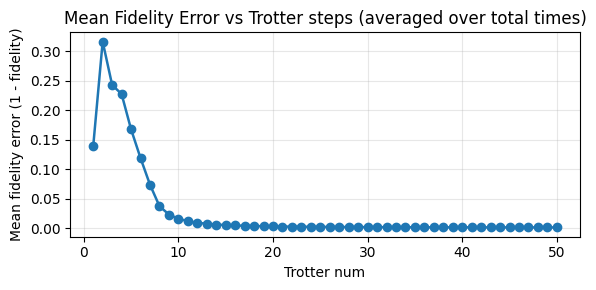

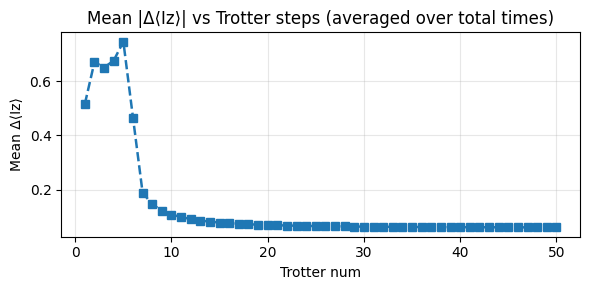

In [36]:
# ----- Mean errors across total evolution times vs Trotter steps -----
from qutip import fidelity, expect, jmat
import numpy as np
import matplotlib.pyplot as plt

# Spin operator
j = 7/2
Iz = jmat(j, 'z')

assert len(rho_traj_all_direct) == len(trotter_results), "Mismatch: direct vs trotter sweep lengths."

# Assume same trotter_num_list used for every t_max
t_nums = np.array(trotter_results[0]["trotter_num_list"], dtype=int)
t_nums_sorted = np.sort(t_nums)
n_tmax  = len(trotter_results)
n_tnums = len(t_nums_sorted)

# Collect per-t_max errors aligned to sorted trotter numbers
fid_err_matrix = np.zeros((n_tmax, n_tnums), dtype=float)  # rows: t_max, cols: trotter_num
iz_err_matrix  = np.zeros((n_tmax, n_tnums), dtype=float)

for idx, TR in enumerate(trotter_results):
    # Direct reference final state at this t_max
    rho_ref = rho_traj_all_direct[idx][-1]
    Iz_ref = expect(Iz, rho_ref)

    # Map results to sorted trotter_num order
    tlist = np.array(TR["trotter_num_list"], dtype=int)
    order = np.argsort(tlist)

    # Finals for each trotter_num
    final_rhos = [rho_list[-1] for rho_list in TR["rho_trajectories"]]
    fids = np.array([fidelity(rho_i, rho_ref) for rho_i in final_rhos])[order]
    Iz_vals = np.array([expect(Iz, rho_i) for rho_i in final_rhos])[order]
    Iz_diffs = np.abs(Iz_vals - Iz_ref)

    # Store errors aligned to t_nums_sorted
    fid_err_matrix[idx, :] = 1.0 - fids
    iz_err_matrix[idx, :]  = Iz_diffs

# Mean across all total times for each trotter number
mean_fid_err = fid_err_matrix.mean(axis=0)
mean_iz_err  = iz_err_matrix.mean(axis=0)

# -------- Plot A: Mean fidelity error vs Trotter steps --------
plt.figure(figsize=(6, 3))
plt.plot(t_nums_sorted, mean_fid_err, marker='o', linewidth=1.8)
plt.xlabel("Trotter num")
plt.ylabel("Mean fidelity error (1 - fidelity)")
plt.title("Mean Fidelity Error vs Trotter steps (averaged over total times)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------- Plot B: Mean Δ⟨Iz⟩ vs Trotter steps --------
plt.figure(figsize=(6, 3))
plt.plot(t_nums_sorted, mean_iz_err, marker='s', linestyle='--', linewidth=1.8)
plt.xlabel("Trotter num")
plt.ylabel("Mean Δ⟨Iz⟩")
plt.title("Mean |Δ⟨Iz⟩| vs Trotter steps (averaged over total times)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Floquet Analysis

In [37]:
eigvals, eigvecs = U.eigenstates() #H_drive.eigenstates()

# Combine into pairs (val, vec)
eigpairs = list(zip(eigvals, eigvecs))

# Sort explicitly by eigenvalue
eigpairs_sorted = sorted(eigpairs, key=lambda x: x[0])

# Unpack back into separate lists
eigvals_sorted, eigvecs_sorted = zip(*eigpairs_sorted)

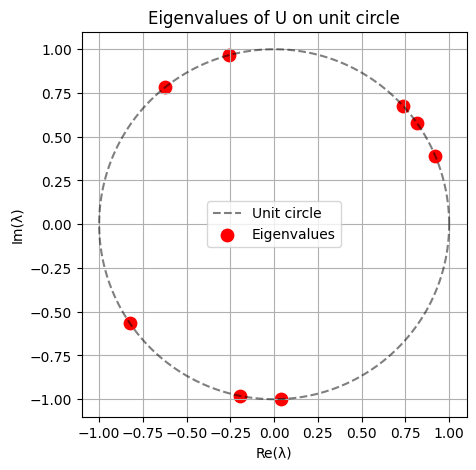

In [38]:
# Unit circle for reference
theta = np.linspace(0, 2*np.pi, 400)
circle_x = np.cos(theta)
circle_y = np.sin(theta)

# Plot
plt.figure(figsize=(5,5))
plt.plot(circle_x, circle_y, 'k--', alpha=0.5, label='Unit circle')  # unit circle
plt.scatter(np.array(eigvals_sorted).real, np.array(eigvals_sorted).imag, color='red', s=80, label='Eigenvalues')

plt.gca().set_aspect('equal')
plt.xlabel("Re(λ)")
plt.ylabel("Im(λ)")
plt.title("Eigenvalues of U on unit circle")
plt.legend()
plt.grid(True)
plt.show()

# Poincare Section

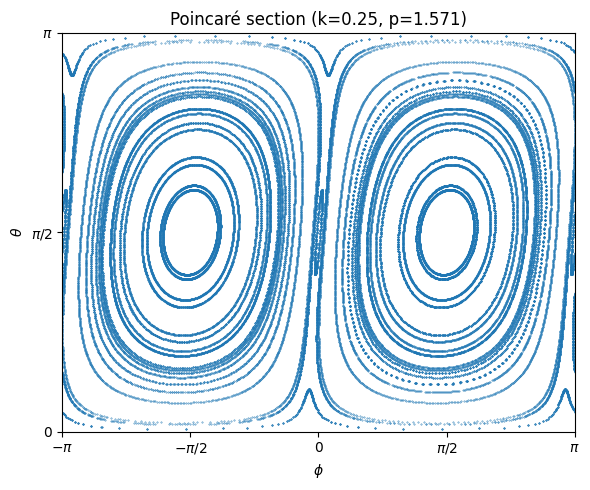

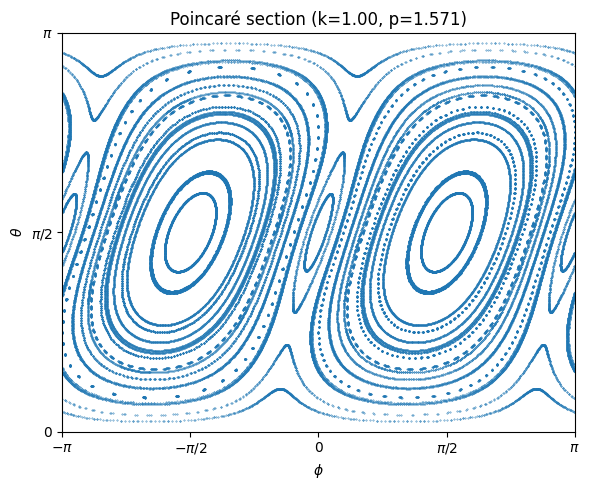

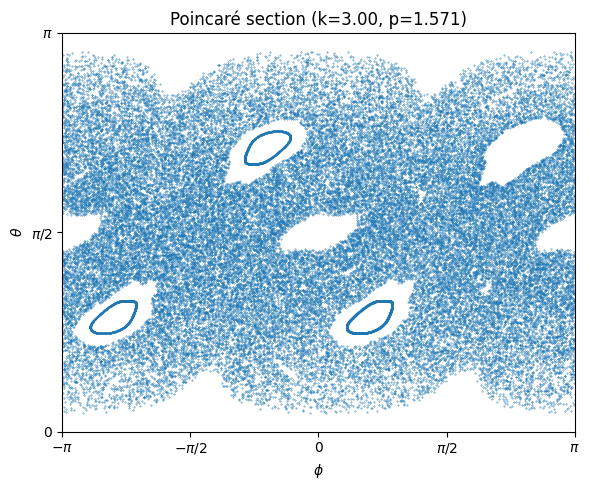

In [39]:
# Retry: Poincaré sections for the classical kicked top

def rotate_y(v, angle):
    c, s = np.cos(angle), np.sin(angle)
    x, y, z = v[...,0], v[...,1], v[...,2]
    x2 =  c*x + s*z
    y2 =  y
    z2 = -s*x + c*z
    return np.stack([x2, y2, z2], axis=-1)

def rotate_z(v, angle):
    c, s = np.cos(angle), np.sin(angle)
    x, y, z = v[...,0], v[...,1], v[...,2]
    x2 =  c*x - s*y
    y2 =  s*x + c*y
    z2 =  z
    return np.stack([x2, y2, z2], axis=-1)

def kicked_top_step(v, k, p):
    angle = k * v[...,2]           # nonlinear twist about z
    v1 = rotate_z(v, angle)
    v2 = rotate_y(v1, p)           # rotation about y
    v2 = v2 / np.linalg.norm(v2, axis=-1, keepdims=True)
    return v2

def spherical_angles(v):
    x, y, z = v[...,0], v[...,1], v[...,2]
    theta = np.arccos(np.clip(z, -1.0, 1.0))
    phi = np.arctan2(y, x)
    return phi, theta

def poincare_section(k, p=np.pi/2, n_seeds_phi=5, n_seeds_theta=8, n_iter=1500, n_discard=100):
    phis = np.linspace(-np.pi, np.pi, n_seeds_phi, endpoint=False)
    thetas = np.linspace(0.15*np.pi, 0.85*np.pi, n_seeds_theta)
    seeds = []
    for th in thetas:
        for ph in phis:
            seeds.append(np.array([np.cos(ph)*np.sin(th), np.sin(ph)*np.sin(th), np.cos(th)]))
    seeds = np.stack(seeds, axis=0)

    pts_phi, pts_theta = [], []
    v = seeds.copy()
    for i in range(n_iter):
        v = kicked_top_step(v, k, p)
        if i >= n_discard:
            ph, th = spherical_angles(v)
            pts_phi.append(ph.ravel())
            pts_theta.append(th.ravel())

    return np.concatenate(pts_phi), np.concatenate(pts_theta)

p = np.pi/2
k_list = [0.25, 1.0, 3.0]

for k in k_list:
    ph, th = poincare_section(k, p=p)
    plt.figure(figsize=(6,5))
    plt.scatter(ph, th, s=0.1)
    plt.xlabel(r'$\phi$')
    plt.ylabel(r'$\theta$')
    plt.title(f'Poincaré section (k={k:.2f}, p={p:.3f})')
    plt.xlim([-np.pi, np.pi])
    plt.ylim([0, np.pi])
    plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
    plt.yticks([0, np.pi/2, np.pi], [r'$0$', r'$\pi/2$', r'$\pi$'])
    plt.tight_layout()

## DQS Poincare Section

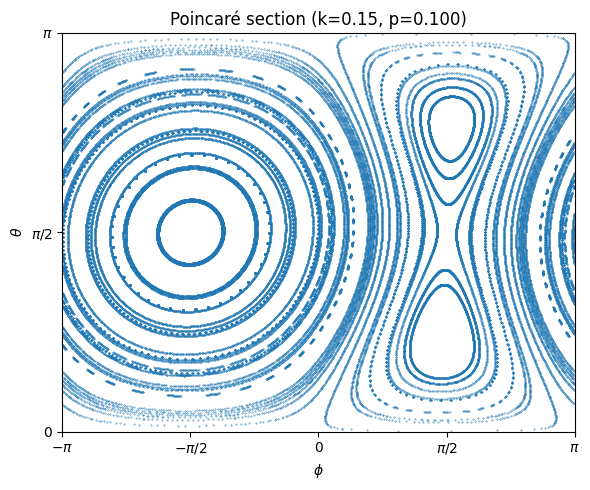

In [40]:
# Physical parameters
rabi_strength = 2*np.pi*1/(2*(1888409/1e9))   # rad/s
tau = 60e-6#(2*(1888409/1e9))/4                     # seconds

# Derived parameters
p = rabi_strength * tau                       # rotation about y
k = 2*np.pi*400 * tau # 2*np.pi*505.6794680343994 * tau         #2*np.pi*800 * tau                 # nonlinear twist strength


ph, th = poincare_section(k, p=p)
plt.figure(figsize=(6,5))
plt.scatter(ph, th, s=0.1)
plt.xlabel(r'$\phi$')
plt.ylabel(r'$\theta$')
plt.title(f'Poincaré section (k={k:.2f}, p={p:.3f})')
plt.xlim([-np.pi, np.pi])
plt.ylim([0, np.pi])
plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
plt.yticks([0, np.pi/2, np.pi], [r'$0$', r'$\pi/2$', r'$\pi$'])
plt.tight_layout()

# OTOC

## 1. No reversing sequence

In [41]:
from qutip import jmat, basis, ket2dm, commutator

# ---------- Spin & generators ----------
j = 7/2
Jx, Jy, Jz = jmat(j)
d = int(2*j + 1)

# ---------- Helper: |j,m> index (QuTiP uses |j,j> at index 0) ----------
def m_to_index(j, m):
    return int(j - m)

# ---------- Displacement (a.k.a. R(θ,φ) in the paper) ----------
def displacement(theta, phi, Jx, Jy):
    """
    R(θ,φ) = exp{-i θ [ -sinφ Jx + cosφ Jy ]}  (Eq. 30)
    This rotates |j,j> to the spin-coherent |θ,φ>.
    """
    return (-1j * theta * (-np.sin(phi)*Jx + np.cos(phi)*Jy)).expm()

# ---------- Spin-coherent ket and projector ----------
def scs_ket(j, theta, phi, Jx, Jy, Jz):
    R = displacement(theta, phi, Jx, Jy)
    ket_jj = basis(int(2*j+1), 0)  # |j,j>
    return R * ket_jj

def projector_V(j, theta, phi, Jx, Jy, Jz):
    psi = scs_ket(j, theta, phi, Jx, Jy, Jz)
    return ket2dm(psi)

# ---------- Axis n(Ω) in spherical angles (Eq. 28) ----------
def n_spherical(theta, phi):
    return np.array([np.sin(theta)*np.cos(phi),
                     np.sin(theta)*np.sin(phi),
                     np.cos(theta)], dtype=float)

# ---------- Wε(Ω): two equivalent constructions ----------
def W_eps_direct(theta, phi, eps, Jx, Jy, Jz):
    n = n_spherical(theta, phi)
    nx, ny, nz = n / np.linalg.norm(n)
    return (-1j * eps * (nx*Jx + ny*Jy + nz*Jz)).expm()

def W_eps_conjugation(theta, phi, eps, Jx, Jy, Jz):
    R = displacement(theta, phi, Jx, Jy)  # this is RW(θ,φ) in Eq. 30
    return R * (-1j * eps * Jz).expm() * R.dag()

# ---------- Quick check: [V, W] = 0 initially ----------
theta, phi, eps = np.pi/2, 0, 0.25
V = projector_V(j, theta, phi, Jx, Jy, Jz)
W1 = W_eps_direct(theta, phi, eps, Jx, Jy, Jz)
W2 = W_eps_conjugation(theta, phi, eps, Jx, Jy, Jz)

print("||[V,W_direct]||  =", (commutator(V, W1)).norm())
print("||[V,W_conj]||    =", (commutator(V, W2)).norm())

||[V,W_direct]||  = 7.933664171941826e-16
||[V,W_conj]||    = 1.3151159591546635e-15


In [42]:
F_t, W_expect = otoc_from_populations(m_vals, probs, eps)
print("F(t) from populations =", F_t)
print("<W(t)> from populations =", W_expect)

NameError: name 'otoc_from_populations' is not defined

In [ ]:
plt.plot(probs)

In [ ]:
# --- Setup reused objects ---
d = int(2*j+1)
R = displacement(theta, phi, Jx, Jy)
Rdag = R.dag()
psi0 = scs_ket(j, theta, phi, Jx, Jy, Jz)

# Jz eigen m-values and kets (|j,m>)
m_vals = np.arange(j, -j-1, -1)  # j, j-1, ..., -j
jm_kets = [basis(d, m_to_index(j, m)) for m in m_vals]

def probs_in_Hprime_basis(state):
    """Return |c_m|^2 after applying R^\dagger to the given state."""
    phi_t = Rdag * state
    return [abs((ket.dag() * phi_t))**2 for ket in jm_kets]

def otoc_from_populations(m_vals, probs, eps):
    mu = np.exp(-1j * eps * np.array(m_vals))
    W_expect = np.sum(np.array(probs) * mu)
    return abs(W_expect)**2, W_expect

# --- Sweep over Trotter numbers ---
trotter_num = 50
trotter_num_list = np.flip(np.arange(1, trotter_num+1))  # 50,49,...,1
t_max = 1.2e-3  # use your existing scalar (seconds)

F_traces = {}  # N -> list of F_k for k=1..N

for N in trotter_num_list:
    dt = t_max / N
    U_step = (-1j * H_drive * dt).expm()

    psi = psi0
    F_list = []
    for k in range(1, N+1):
        psi = U_step * psi
        probs = probs_in_Hprime_basis(psi)
        F_k, _ = otoc_from_populations(m_vals, probs, eps)
        F_list.append(float(np.real_if_close(F_k)))
    F_traces[int(N)] = F_list

# --- Plot: OTOC vs Trotter step index for each N ---
plt.figure(figsize=(9,5))
for N, F_list in F_traces.items():
    x = np.arange(1, N+1)
    plt.plot(x, F_list, alpha=0.25)  # many curves; keep translucent

# Optionally highlight a few representative Ns
for N_high in [50, 25, 10, 5, 1]:
    if N_high in F_traces:
        x = np.arange(1, N_high+1)
        plt.plot(x, F_traces[N_high], linewidth=2)

plt.xlabel("Trotter step index k")
plt.ylabel("F(k·dt) = |⟨W(t)⟩|²")
plt.title("OTOC traces for varying Trotter numbers (dt = t_max / N)")
plt.tight_layout()
plt.show()

# --- If you also want one value per N at final time t_max (i.e., k=N) ---
for N, F_list in F_traces.items():
    dt = t_max / N
    t_axis = np.arange(1, N+1) * dt
    plt.plot(t_axis, F_list, alpha=0.25)

plt.figure(figsize=(7,4))
plt.ylim([0,1])
plt.plot(N_list_sorted, F_final, marker='o')
plt.xlabel("Trotter number N")
plt.ylabel("F(t_max)")
plt.title("OTOC at fixed total time t_max vs. Trotter number")
plt.tight_layout()
plt.show()